# CQT info — opus

Inspect cached CQT features for a single dataset: shape, example spectrograms, per-class grids.

**Artifacts**
- Audio: `datasets/opus/{class}/*`
- Features: `features/opus-training.npz` (run `cqt-extraction.ipynb` if missing)

Sibling notebooks: `notebooks/vivo/cqt-info.ipynb`, `notebooks/thinkpad/cqt-info.ipynb`.

In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa

EXPERIMENT_RANDOM_STATE = 42
random.seed(EXPERIMENT_RANDOM_STATE)
np.random.seed(EXPERIMENT_RANDOM_STATE)

# --- per-dataset config (this notebook is under notebooks/opus/) ---
DATASET = "opus"
FEATURES_NAME = "opus-training.npz"  # vivo/thinkpad: "{DATASET}.npz"

root_dir = "../../"
dataset_dir = os.path.join(root_dir, "datasets", DATASET)
features_path = os.path.join(root_dir, "features", FEATURES_NAME)

fmin = librosa.note_to_hz("C1")
hop_length = 512
bins_per_octave = 36
sr_default = 48_000

print({
    "dataset": DATASET,
    "dataset_dir": dataset_dir,
    "features_path": features_path,
})

# Read Features

In [2]:
if os.path.exists(features_path):
    data = np.load(features_path)
    exp_features = np.asarray(data["features"])
    exp_labels = np.asarray(data["labels"])
else:
    raise FileNotFoundError(
        f"Expected features file was not found: {features_path}\n"
        f"Run notebooks/{DATASET}/cqt-extraction.ipynb first."
    )

max_cqt_pad_len = exp_features.shape[2] if exp_features.ndim == 3 else 200

print(f"Loaded features: {exp_features.shape}")
print(f"Loaded labels:   {exp_labels.shape}")
print(f"Unique classes:  {len(np.unique(exp_labels))}")

Loaded features: (7200, 216, 188)
Loaded labels:   (7200,)
Unique classes:  36


# 1. Visualize What Is Inside A CQT Frame

Sample index: 642
Label: A_diminished_4
CQT shape (bins x frames): (216, 188)


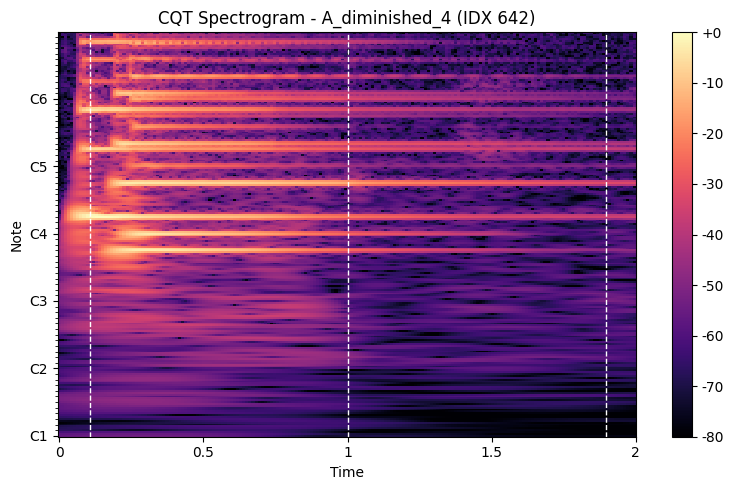

In [3]:
rng = np.random.default_rng(EXPERIMENT_RANDOM_STATE)
import librosa.display

sample_idx = int(rng.integers(0, len(exp_features)))
sample_cqt = exp_features[sample_idx]
sample_label = exp_labels[sample_idx]

bins_per_note = bins_per_octave // 12
n_notes = int(np.ceil(sample_cqt.shape[0] / bins_per_note))

start_midi = librosa.note_to_midi("C1")
note_names = np.repeat(
    [librosa.midi_to_note(m, octave=True) for m in range(start_midi, start_midi + n_notes)],
    bins_per_note
)[:sample_cqt.shape[0]]

n_frames = sample_cqt.shape[1]
time_axis = np.arange(n_frames) * hop_length / sr_default

frame_a = min(10, n_frames - 1)
frame_b = n_frames // 2
frame_c = max(n_frames - 10, 0)
frame_points = [frame_a, frame_b, frame_c]

print(f'Sample index: {sample_idx}')
print(f'Label: {sample_label}')
print(f'CQT shape (bins x frames): {sample_cqt.shape}')

plt.figure(figsize=(8, 5))
librosa.display.specshow(
    sample_cqt,
    x_axis='time',
    y_axis='cqt_note',
    sr=sr_default,
    fmin=fmin,
    bins_per_octave=bins_per_octave,
    hop_length=hop_length,
)
for fp in frame_points:
    plt.axvline(fp * hop_length / sr_default, color='white', linestyle='--', linewidth=1)
plt.title(f'CQT Spectrogram - {sample_label} (IDX {sample_idx})')
plt.colorbar(format='%+2.0f')
plt.tight_layout()
plt.show()

### 1.1 Frame-Level Note Energy At Selected Time Steps

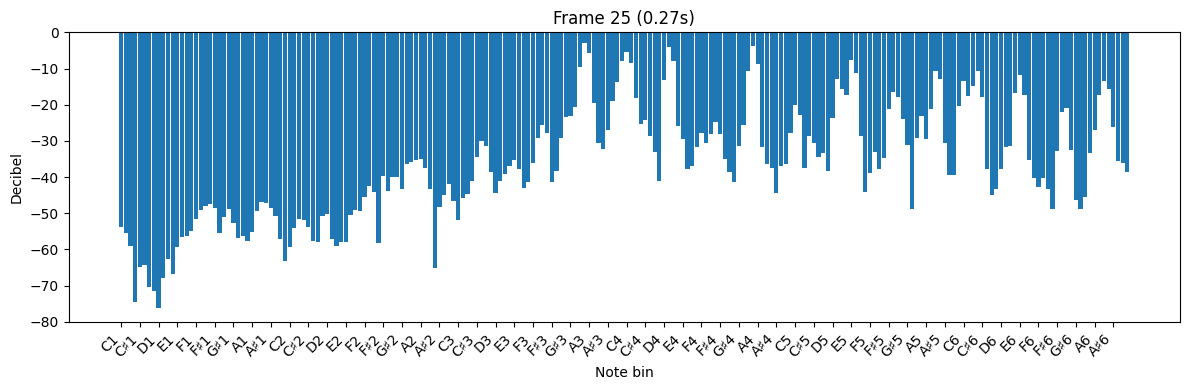

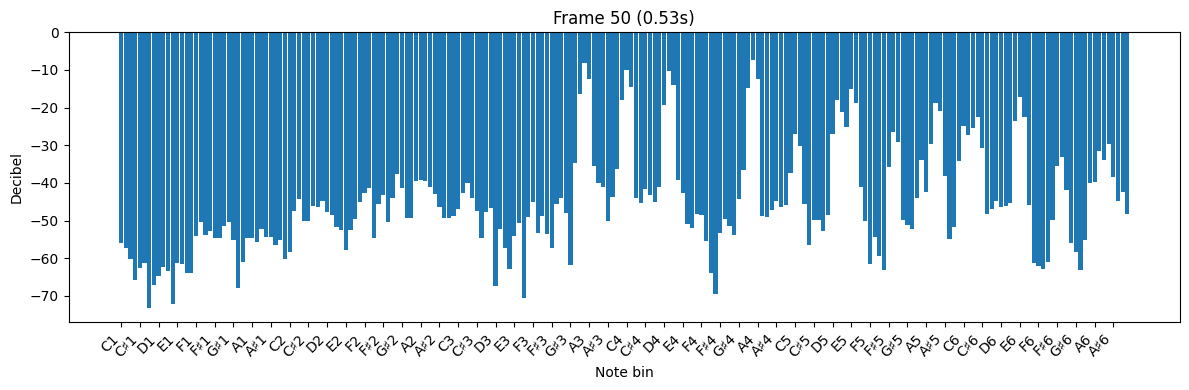

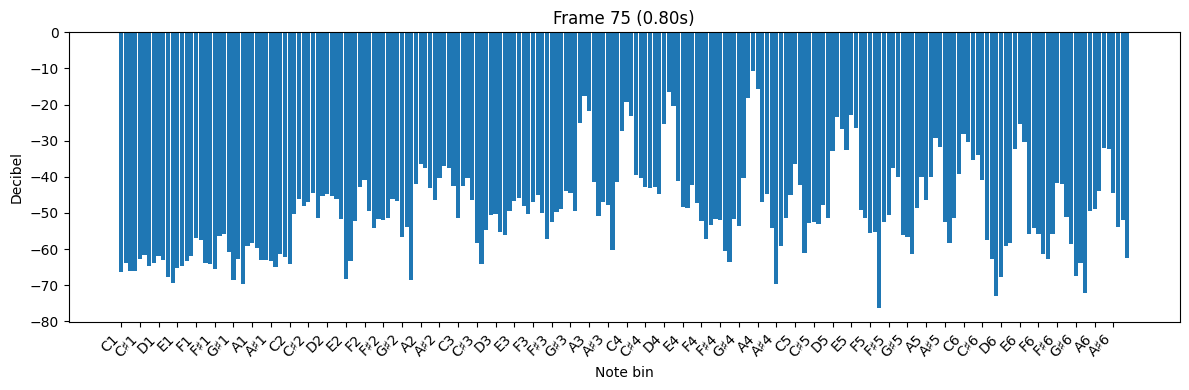

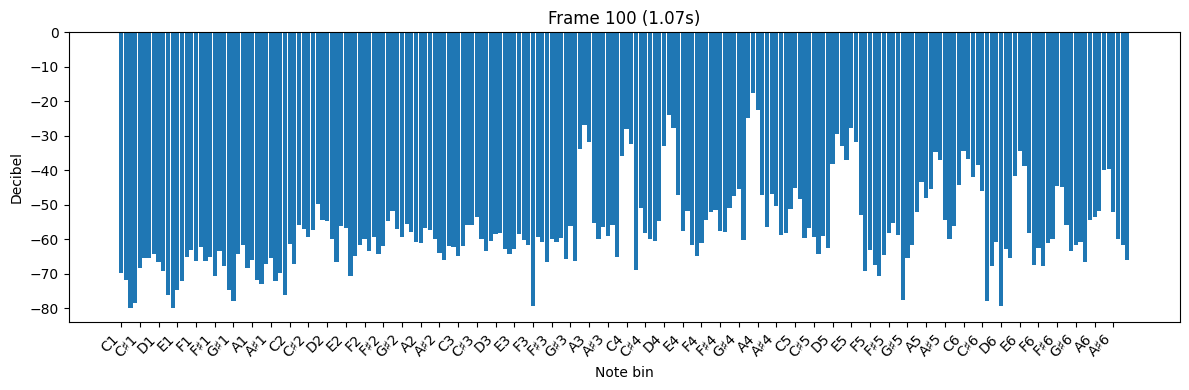

In [4]:
frame_points = [25, 50, 75, 100]
if sample_cqt.shape[1] <= max(frame_points):
    raise ValueError(f'Need at least {max(frame_points) + 1} frames, got {sample_cqt.shape[1]}')

for fp in frame_points:
    plt.figure(figsize=(12, 4))
    plt.bar(np.arange(len(note_names)), sample_cqt[:, fp], width=0.9)
    plt.title(f'Frame {fp} ({fp * hop_length / sr_default:.2f}s)')
    plt.xlabel('Note bin')
    plt.ylabel('Decibel')
    plt.xticks(np.arange(len(note_names))[::4], note_names[::4], rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

### 1.2 3D CQT Surface View

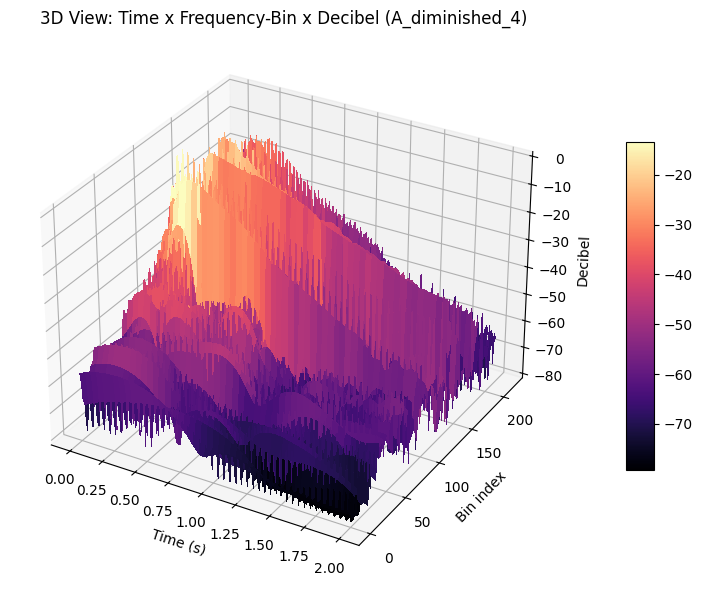

In [5]:
X, Y = np.meshgrid(time_axis, np.arange(sample_cqt.shape[0]))
fig = plt.figure(figsize=(14, 6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, sample_cqt, cmap='magma', linewidth=0, antialiased=False)
ax.set_title(f'3D View: Time x Frequency-Bin x Decibel ({sample_label})')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Bin index')
ax.set_zlabel('Decibel')
fig.colorbar(surf, shrink=0.6, aspect=12)
plt.tight_layout()
plt.show()

### 1.3 Data Frame Table

In [6]:
sample_df = pd.DataFrame(
    sample_cqt,
    index=note_names,
    columns=[f'frame_{i}' for i in range(sample_cqt.shape[1])],
    dtype=float,
)

with pd.option_context("display.max_rows", None, "display.max_columns", None):
  display(sample_df)

,frame_0,frame_1,frame_2,frame_3,frame_4,frame_5,frame_6,frame_7,frame_8,frame_9,frame_10,frame_11,frame_12,frame_13,frame_14,frame_15,frame_16,frame_17,frame_18,frame_19,frame_20,frame_21,frame_22,frame_23,frame_24,frame_25,frame_26,frame_27,frame_28,frame_29,frame_30,frame_31,frame_32,frame_33,frame_34,frame_35,frame_36,frame_37,frame_38,frame_39,frame_40,frame_41,frame_42,frame_43,frame_44,frame_45,frame_46,frame_47,frame_48,frame_49,frame_50,frame_51,frame_52,frame_53,frame_54,frame_55,frame_56,frame_57,frame_58,frame_59,frame_60,frame_61,frame_62,frame_63,frame_64,frame_65,frame_66,frame_67,frame_68,frame_69,frame_70,frame_71,frame_72,frame_73,frame_74,frame_75,frame_76,frame_77,frame_78,frame_79,frame_80,frame_81,frame_82,frame_83,frame_84,frame_85,frame_86,frame_87,frame_88,frame_89,frame_90,frame_91,frame_92,frame_93,frame_94,frame_95,frame_96,frame_97,frame_98,frame_99,frame_100,frame_101,frame_102,frame_103,frame_104,frame_105,frame_106,frame_107,frame_108,frame_109,frame_110,frame_111,frame_112,frame_113,frame_114,frame_115,frame_116,frame_117,frame_118,frame_119,frame_120,frame_121,frame_122,frame_123,frame_124,frame_125,frame_126,frame_127,frame_128,frame_129,frame_130,frame_131,frame_132,frame_133,frame_134,frame_135,frame_136,frame_137,frame_138,frame_139,frame_140,frame_141,frame_142,frame_143,frame_144,frame_145,frame_146,frame_147,frame_148,frame_149,frame_150,frame_151,frame_152,frame_153,frame_154,frame_155,frame_156,frame_157,frame_158,frame_159,frame_160,frame_161,frame_162,frame_163,frame_164,frame_165,frame_166,frame_167,frame_168,frame_169,frame_170,frame_171,frame_172,frame_173,frame_174,frame_175,frame_176,frame_177,frame_178,frame_179,frame_180,frame_181,frame_182,frame_183,frame_184,frame_185,frame_186,frame_187
C1,-56.758446,-56.521530,-56.295700,-56.080627,-55.876434,-55.682190,-55.498154,-55.324287,-55.160004,-55.005478,-54.860313,-54.724510,-54.597786,-54.479919,-54.371033,-54.270973,-54.179718,-54.096687,-54.022125,-53.955917,-53.897820,-53.848259,-53.806564,-53.772919,-53.747231,-53.729622,-53.719803,-53.717964,-53.724083,-53.738037,-53.760056,-53.790031,-53.828262,-53.874435,-53.928719,-53.991188,-54.061966,-54.141335,-54.229286,-54.326065,-54.431465,-54.545906,-54.669472,-54.802490,-54.945175,-55.097565,-55.260208,-55.433075,-55.616547,-55.811050,-56.016846,-56.234390,-56.463783,-56.705711,-56.960243,-57.228355,-57.509796,-57.805824,-58.116608,-58.442757,-58.785194,-59.144440,-59.521034,-59.915833,-60.330025,-60.764252,-61.219429,-61.696152,-62.196068,-62.719620,-63.267792,-63.842087,-64.442780,-65.069656,-65.723358,-66.403214,-67.106171,-67.829582,-68.567146,-69.308754,-70.041382,-70.743469,-71.391663,-71.955482,-72.406143,-72.719963,-72.885483,-72.909813,-72.810661,-72.618790,-72.361458,-72.067871,-71.759567,-71.451698,-71.156517,-70.879021,-70.625511,-70.398384,-70.199448,-70.027786,-69.883980,-69.768448,-69.677612,-69.611549,-69.570023,-69.551636,-69.555222,-69.579735,-69.624123,-69.687393,-69.768532,-69.866539,-69.980453,-70.109306,-70.252098,-70.407867,-70.575615,-70.754349,-70.943047,-71.140656,-71.346146,-71.558418,-71.776390,-71.998955,-72.224983,-72.453362,-72.682968,-72.912712,-73.141525,-73.368385,-73.591866,-73.812508,-74.027496,-74.238258,-74.441772,-74.639908,-74.829536,-75.008713,-75.179596,-75.340759,-75.496239,-75.653481,-75.801979,-75.933388,-76.056419,-76.190445,-76.320518,-76.436638,-76.551155,-76.651230,-76.755341,-76.859169,-76.972893,-77.060799,-77.167732,-77.252754,-77.330963,-77.394470,-77.467361,-77.530869,-77.585190,-77.639709,-77.690392,-77.715370,-77.736855,-77.748772,-77.756401,-77.776299,-77.767014,-77.754234,-77.744286,-77.722145,-77.706337,-77.685677,-77.670250,-77.649719,-77.630615,-77.597633,-77.578087,-77.549080,-77.513412,-77.494827,-77.461044,-77.463333,-77.431366,-77.416031,-77.396637,-77.380608
C1,-58.122429,-57.911812,-57.710358,-57.517517,-57.333199,-57.160278,-56.994171,-56.836365,-56.688049,-56.546379,-56.415070,-56.290588,-56.174416,-56.067055,-

# 2. Group Visualization

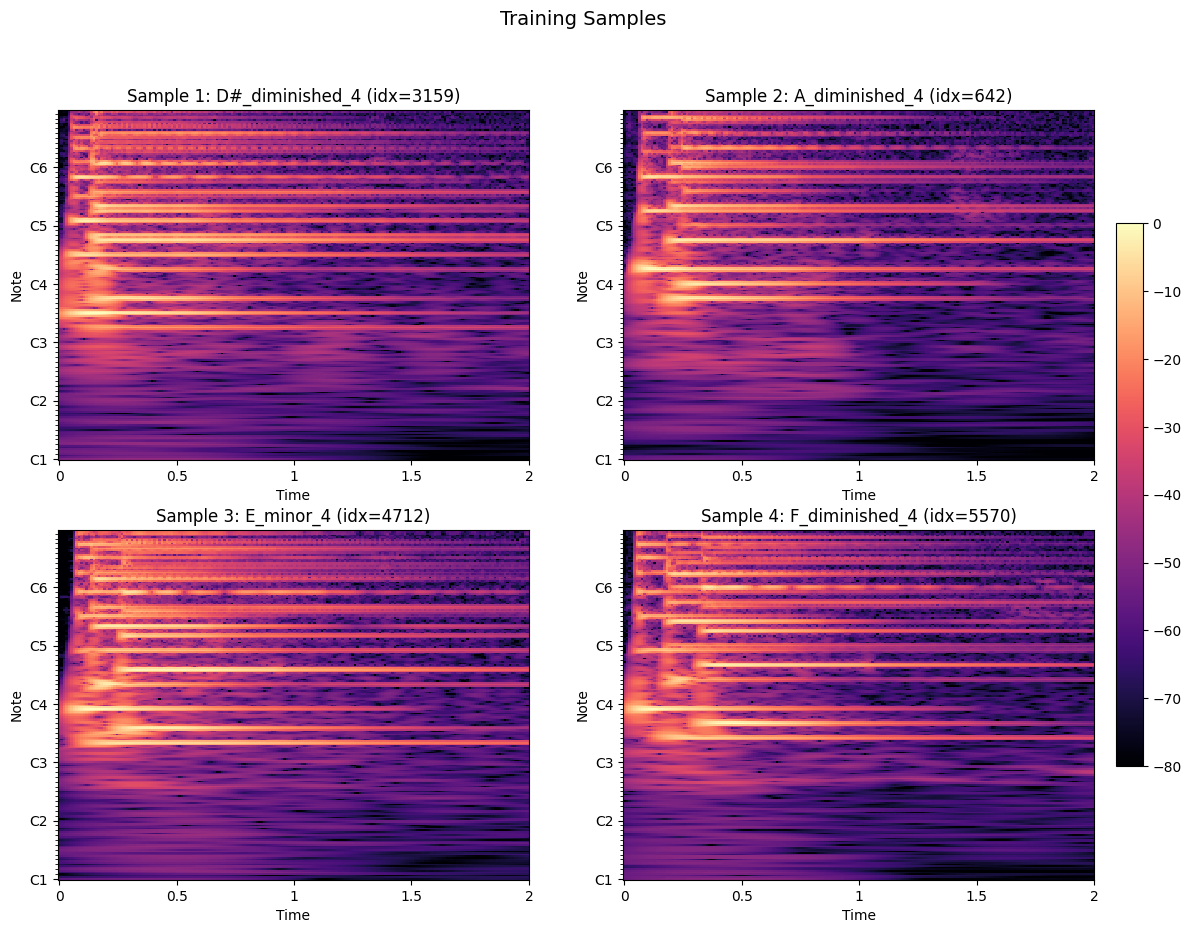

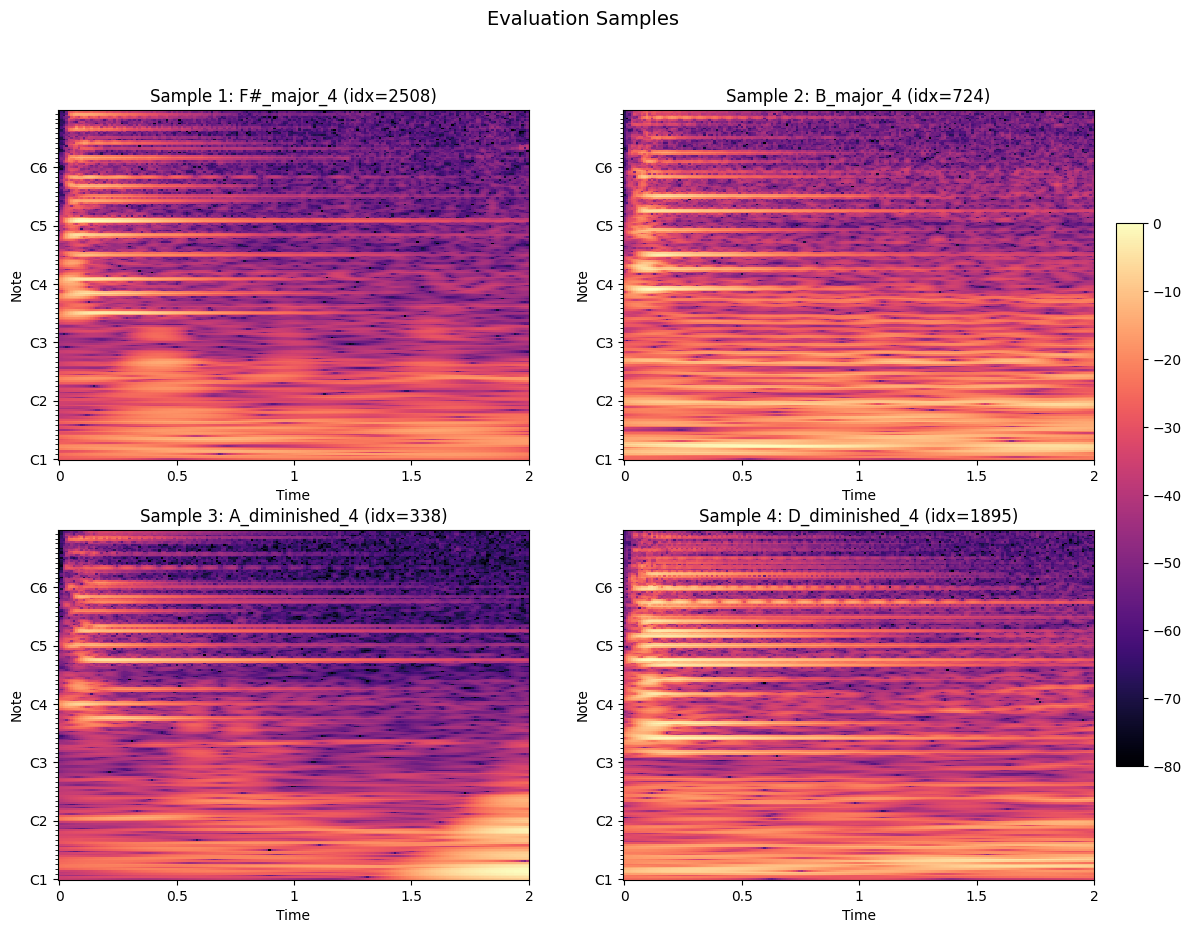

In [7]:
rng_group = np.random.default_rng(EXPERIMENT_RANDOM_STATE)

def plot_random_cqt_grid(features, labels, title, n_samples=4):
    if features.ndim != 3:
        raise RuntimeError(f'Expected features with shape (N, bins, frames), got {features.shape}')

    n_show = min(n_samples, len(features))
    if n_show == 0:
        raise RuntimeError(f'No samples available for {title.lower()}')

    sample_indices = rng_group.choice(len(features), size=n_show, replace=False)
    fig, axes = plt.subplots(2, 2, figsize=(14, 10), squeeze=False)
    axes_flat = axes.flatten()

    # vmin = float(np.percentile(features[sample_indices], 2))
    # vmax = float(np.percentile(features[sample_indices], 98))
    last_im = None

    for sample_number, (ax, sample_idx) in enumerate(zip(axes_flat, sample_indices), start=1):
        sample_cqt = features[sample_idx]
        sample_label = labels[sample_idx]
        last_im = librosa.display.specshow(
            sample_cqt,
            ax=ax,
            x_axis='time',
            y_axis='cqt_note',
            sr=sr_default,
            fmin=fmin,
            bins_per_octave=bins_per_octave,
            hop_length=hop_length,
            cmap='magma',
            # vmin=vmin,
            # vmax=vmax,
        )
        ax.set_title(f'Sample {sample_number}: {sample_label} (idx={int(sample_idx)})')
        ax.set_xlabel('Time')
        ax.set_ylabel('Note')

    for ax in axes_flat[n_show:]:
        ax.axis('off')

    fig.suptitle(title, fontsize=14, y=0.98)
    fig.colorbar(last_im, ax=axes, fraction=0.025, pad=0.02)
    plt.show()

plot_random_cqt_grid(
    exp_features,
    exp_labels,
    f'{DATASET} samples',
)

# Cross-dataset / train-vs-eval comparison

This notebook is **single-dataset only**. Former train-vs-eval and noise-bias sections were removed so each of `opus` / `vivo` / `thinkpad` can be analyzed independently.

For device comparison, open the sibling `cqt-info.ipynb` under each dataset folder (after running that folder’s `cqt-extraction.ipynb`).